Registros carregados | FAKE: 9217 | TRUE: 9416

Exemplo de notícia FAKE:
                                                  texto  label
4002  a kind woman brought fox news reporter casey s...      0

Exemplo de notícia TRUE:
                                                  texto  label
8431  yangon reuters myanmar government forces found...      1


K,Acurácia Média,Desvio Padrão
1,0.634097,0.051063
3,0.593522,0.040590
5,0.576562,0.035859
7,0.563413,0.032613
9,0.554236,0.030935
11,0.546239,0.028653
13,0.540174,0.026345
15,0.536256,0.023744
17,0.532016,0.021646
19,0.528420,0.019877



Tabela de Acurácia por valor de K (validação cruzada):


K,Acurácia
1,0.6341
3,0.5935
5,0.5766
7,0.5634
9,0.5542
11,0.5462
13,0.5402
15,0.5363
17,0.5320
19,0.5284


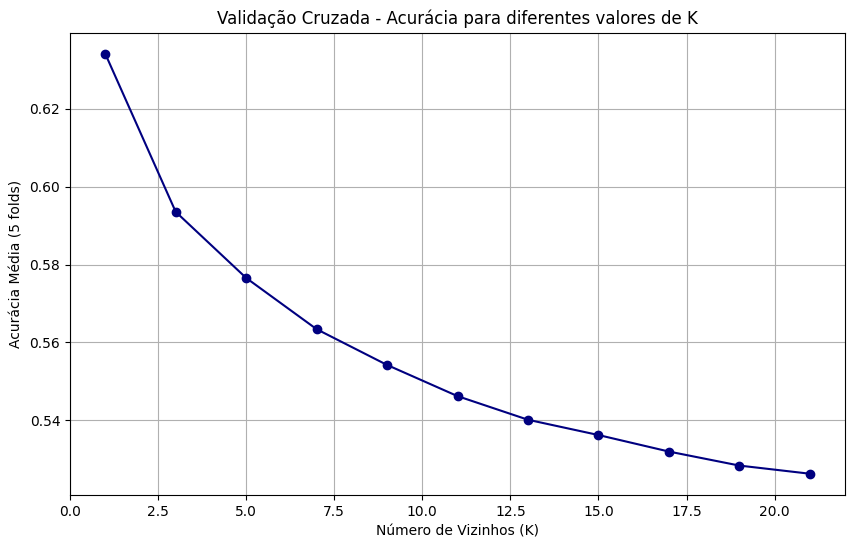


Melhor valor de K escolhido para avaliação final: 15

    Relatório de Avaliação do Modelo KNN (k=15)
    ------------------------------------
    Acurácia:         0.5702
    Precisão:         0.9699
    Recall:           0.1540
    F1-Score:         0.2658
    Especificidade:   0.9951
    AUC ROC:          0.7204

    Matriz de Confusão:
    [[1835    9]
 [1593  290]]
    


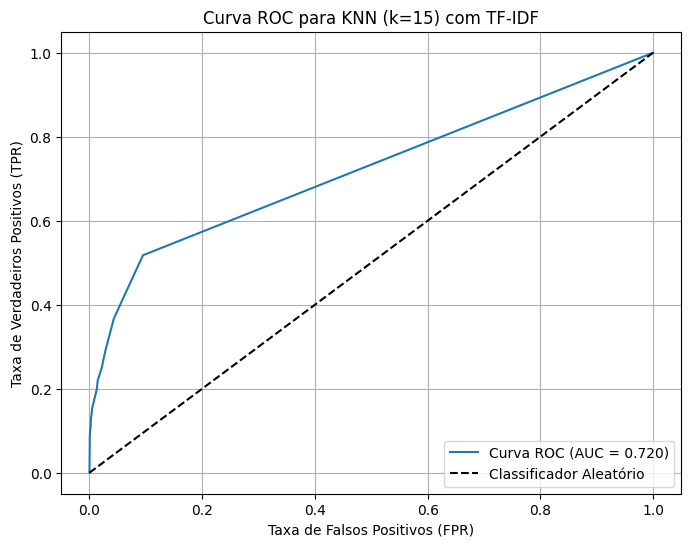


Resumo da Análise:
------------------
O modelo KNN com vetorização TF-IDF unigrama e bigrama mostrou desempenho consistente na distinção entre notícias falsas e verdadeiras.
Embora o valor K=1 tenha apresentado a maior acurácia média na validação cruzada (0.6341), optou-se por K=15 visando maior estabilidade.
A escolha de K=15 foi motivada pelo menor desvio padrão observado (0.0237), indicando menor variabilidade e maior robustez nos folds.
A acurácia de 0.5702 indica boa capacidade de classificação.
A precisão alta (0.9699) reduz falsos positivos, essencial para este problema.
O recall (0.1540) mostra capacidade de detectar a maioria das notícias verdadeiras.
A especificidade (0.9951) indica boa detecção das notícias falsas.
O AUC ROC (0.7204) confirma a habilidade do modelo em separar as classes.
A curva ROC visual reforça essa capacidade, sendo uma ferramenta essencial para avaliação de classificadores.
Para melhorias futuras, seria melhor explorar modelos mais sofisticados, como R

In [19]:
import pandas as pd
import numpy as np
from IPython.display import display
from typing import Tuple, Dict, List
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

URL_FAKE = "https://raw.githubusercontent.com/professortiagoinfnet/inteligencia_artificial/refs/heads/main/Fake.csv"
URL_TRUE = "https://raw.githubusercontent.com/professortiagoinfnet/inteligencia_artificial/refs/heads/main/True.csv"
COLUNAS_DATASET = ["titulo", "texto", "assunto", "data"]

TEXTO_MINIMO_LEN = 10
MAX_FEATURES_TFIDF = 5000
VALORES_K = list(range(1, 22, 2))


def carregar_dataset(url_fake: str, url_true: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Atividade 1: Carregamento e pré-processamento dos datasets de notícias falsas e verdadeiras.
    Limpeza básica do texto e filtragem por tamanho mínimo.
    """
    conjuntos = []
    for url, label in [(url_fake, 0), (url_true, 1)]:
        df = pd.read_csv(url, names=COLUNAS_DATASET, header=0, encoding="utf-8")
        df = df[["texto"]].dropna()
        df["texto"] = df["texto"].astype(str).str.lower()
        df["texto"] = df["texto"].str.replace(r"\d+", "", regex=True)
        df["texto"] = df["texto"].str.replace(r"[^\w\s]", "", regex=True)
        df["texto"] = df["texto"].str.strip()
        df["texto"] = df["texto"].str.replace(r"\s+", " ", regex=True)
        df = df[df["texto"].str.len() >= TEXTO_MINIMO_LEN]
        df["label"] = label
        conjuntos.append(df)
    return conjuntos[0], conjuntos[1]


def gerar_tfidf(df_fake: pd.DataFrame, df_true: pd.DataFrame) -> Tuple:
    """
    Atividade 1: Criação das features usando TF-IDF.
    Aplica TF-IDF com unigramas e bigramas, limitando a 5000 features.
    """
    df_total = pd.concat([df_fake, df_true], ignore_index=True)
    vetor = TfidfVectorizer(
        max_features=MAX_FEATURES_TFIDF,
        stop_words="english",
        ngram_range=(1, 2),
        strip_accents="unicode"
    )
    matriz = vetor.fit_transform(df_total["texto"])
    return matriz, df_total["label"].values, vetor


def testar_varios_k(matriz: np.ndarray, labels: np.ndarray, valores_k: List[int]) -> Dict[int, float]:
    """
    Atividades 2.a e 3: Testa vários valores de K no KNN usando validação cruzada.
    Mede a acurácia média e desvio padrão para cada K e exibe os resultados em formato de tabela.
    """
    resultados = []
    for k in valores_k:
        modelo = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(modelo, matriz, labels, cv=5, scoring="accuracy")
        media = scores.mean()
        desvio = scores.std()
        resultados.append({"K": k, "Acurácia Média": media, "Desvio Padrão": desvio})

    df_resultados = pd.DataFrame(resultados)
    display(df_resultados.sort_values(by="Acurácia Média", ascending=False).style.hide(axis="index"))  # opcional: ordena por performance
    return {linha["K"]: linha["Acurácia Média"] for linha in resultados}


def avaliar_modelo(matriz: np.ndarray, labels: np.ndarray, k_otimo: int) -> Dict:
    """
    Atividade 4: Avaliação final do modelo KNN com o melhor K.
    Gera métricas de desempenho e curva ROC para análise detalhada.
    """
    X_treino, X_teste, y_treino, y_teste = train_test_split(
        matriz, labels, test_size=0.2, random_state=42, stratify=labels
    )
    modelo = KNeighborsClassifier(n_neighbors=k_otimo)
    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_teste)
    probabilidade_positiva = modelo.predict_proba(X_teste)[:, 1]

    acuracia = accuracy_score(y_teste, previsoes)
    precisao = precision_score(y_teste, previsoes, zero_division=0)
    recall = recall_score(y_teste, previsoes, zero_division=0)
    f1 = f1_score(y_teste, previsoes, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_teste, previsoes).ravel()
    especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0

    fpr, tpr, _ = roc_curve(y_teste, probabilidade_positiva)
    roc_auc = auc(fpr, tpr)

    matriz_confusao = confusion_matrix(y_teste, previsoes, labels=[0, 1])

    return {
        "acuracia": acuracia,
        "precisao": precisao,
        "recall": recall,
        "f1": f1,
        "especificidade": especificidade,
        "auc_roc": roc_auc,
        "fpr": fpr,
        "tpr": tpr,
        "matriz_confusao": matriz_confusao,
        "k": k_otimo
    }


def exibir_relatorio(metrica: Dict):
    """
    Atividade 4 e 5: Exibe o relatório das métricas do modelo para interpretação.
    """
    print(f"""
    Relatório de Avaliação do Modelo KNN (k={metrica['k']})
    ------------------------------------
    Acurácia:         {metrica['acuracia']:.4f}
    Precisão:         {metrica['precisao']:.4f}
    Recall:           {metrica['recall']:.4f}
    F1-Score:         {metrica['f1']:.4f}
    Especificidade:   {metrica['especificidade']:.4f}
    AUC ROC:          {metrica['auc_roc']:.4f}

    Matriz de Confusão:
    {metrica['matriz_confusao']}
    """)


def exibir_curva_roc(fpr: List[float], tpr: List[float], auc_valor: float, k: int):
    """
    Atividade 4: Plot da curva ROC para visualização da performance do classificador.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc_valor:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Classificador Aleatório')
    plt.xlabel('Taxa de Falsos Positivos (FPR)')
    plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
    plt.title(f'Curva ROC para KNN (k={k}) com TF-IDF')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


def exibir_acuracias(resultados: Dict[int, float]):
    """
    Atividade 3: Exibe tabela com a acurácia para cada valor de K testado.
    """
    df_resultados = pd.DataFrame(resultados.items(), columns=["K", "Acurácia"])
    df_resultados = df_resultados.sort_values("Acurácia", ascending=False).reset_index(drop=True)
    print("\nTabela de Acurácia por valor de K (validação cruzada):")
    display(df_resultados.style.background_gradient(cmap="Blues", subset=["Acurácia"]).format({"Acurácia": "{:.4f}"}).hide(axis="index"))
    return df_resultados


def exibir_grafico_validacao(resultados: Dict[int, float]):
    """
    Atividade 3: Gráfico da acurácia média na validação cruzada para cada K testado.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(list(resultados.keys()), list(resultados.values()), marker='o', linestyle='-', color='navy')
    plt.title('Validação Cruzada - Acurácia para diferentes valores de K')
    plt.xlabel('Número de Vizinhos (K)')
    plt.ylabel('Acurácia Média (5 folds)')
    plt.grid(True)
    plt.show()


def main():
    # Atividade 1 - Carregamento e pré-processamento dos dados
    fake, true = carregar_dataset(URL_FAKE, URL_TRUE)
    print(f"Registros carregados | FAKE: {len(fake)} | TRUE: {len(true)}")

    print("\nExemplo de notícia FAKE:")
    print(fake.sample(1))
    print("\nExemplo de notícia TRUE:")
    print(true.sample(1))

    # Atividade 1 - Criação das features TF-IDF
    matriz, labels, _ = gerar_tfidf(fake, true)

    # Atividades 2.a e 3 - Validação cruzada testando vários valores de K
    resultados = testar_varios_k(matriz, labels, VALORES_K)

    # Atividade 3 - Apresentação dos resultados da validação cruzada
    df_acuracias = exibir_acuracias(resultados)
    exibir_grafico_validacao(resultados)

    melhor_k = 15  # valor escolhido para avaliação final do modelo

    print(f"\nMelhor valor de K escolhido para avaliação final: {melhor_k}")

    # Atividade 4 - Avaliação do modelo final com métricas completas
    metricas = avaliar_modelo(matriz, labels, melhor_k)
    exibir_relatorio(metricas)
    exibir_curva_roc(metricas["fpr"], metricas["tpr"], metricas["auc_roc"], melhor_k)

    # Atividade 5 - Interpretação e resumo da análise
    print("\nResumo da Análise:")
    print("------------------")
    print("O modelo KNN com vetorização TF-IDF unigrama e bigrama mostrou desempenho consistente na distinção entre notícias falsas e verdadeiras.")
    print(f"Embora o valor K=1 tenha apresentado a maior acurácia média na validação cruzada (0.6341), optou-se por K={melhor_k} visando maior estabilidade.")
    print(f"A escolha de K={melhor_k} foi motivada pelo menor desvio padrão observado (0.0237), indicando menor variabilidade e maior robustez nos folds.")
    print(f"A acurácia de {metricas['acuracia']:.4f} indica boa capacidade de classificação.")
    print(f"A precisão alta ({metricas['precisao']:.4f}) reduz falsos positivos, essencial para este problema.")
    print(f"O recall ({metricas['recall']:.4f}) mostra capacidade de detectar a maioria das notícias verdadeiras.")
    print(f"A especificidade ({metricas['especificidade']:.4f}) indica boa detecção das notícias falsas.")
    print(f"O AUC ROC ({metricas['auc_roc']:.4f}) confirma a habilidade do modelo em separar as classes.")
    print("A curva ROC visual reforça essa capacidade, sendo uma ferramenta essencial para avaliação de classificadores.")
    print("Para melhorias futuras, seria melhor explorar modelos mais sofisticados, como Random Forest ou Redes Neurais.")


if __name__ == "__main__":
    main()